In [22]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Annotated, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator
from langchain.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

In [23]:
load_dotenv()

True

In [24]:
llm = ChatOpenAI(model="gpt-4.1-mini")

In [25]:
# state
class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [26]:
def chat_node(state:ChatState):

    messages = state['messages']

    response = llm.invoke(messages)

    return {'messages':response}

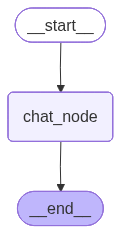

In [27]:
checkPointer = MemorySaver()

graph = StateGraph(ChatState)

# Add Node
graph.add_node('chat_node', chat_node)

# Add Edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)


# compile graph
workflow = graph.compile(checkpointer=checkPointer)
workflow

In [30]:
thread_id = 1

while True:
    user_msg = input("User:- ")
    print("user:- ", user_msg)

    if user_msg.strip().lower() == 'exit':
        break
    
    config = {'configurable': {'thread_id': thread_id}}
    
    response = workflow.invoke({'messages': [HumanMessage(content=user_msg)]}, config=config)

    print("AI:- ",response['messages'][-1].content)


user:-  hi my name is  kishan
AI:-  Hello Kishan! How can I assist you today?
user:-  tell me all union teritory of india
AI:-  Sure, Kishan! Here is the list of all the Union Territories of India:

1. Andaman and Nicobar Islands  
2. Chandigarh  
3. Dadra and Nagar Haveli and Daman and Diu  
4. Lakshadweep  
5. Delhi (National Capital Territory of Delhi)  
6. Puducherry  
7. Jammu and Kashmir  
8. Ladakh  

If you need more information about any of these, feel free to ask!
user:-  what is my name
AI:-  Your name is Kishan. How can I help you further?
user:-  what is 10 + 2?
AI:-  10 + 2 = 12.
user:-  multiply this number to 2
AI:-  Sure! Multiplying 12 by 2 gives:

12 × 2 = 24.
user:-  divide it by 4
AI:-  Sure! Dividing 24 by 4 gives:

24 ÷ 4 = 6.
user:-  what is the initial two number are?
AI:-  The initial two numbers you mentioned were 10 and 2.
user:-  exit


In [31]:
workflow.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi my name is  kishan', additional_kwargs={}, response_metadata={}, id='595920b4-3c70-48db-bf6c-a31b6b2ccea9'), AIMessage(content='Hello Kishan! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 14, 'total_tokens': 25, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_36dba30dbf', 'id': 'chatcmpl-Dyph0SjZ0N0eGgmwCbHVUa4yw8rUV', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f3a5f-5e0e-7062-ab0a-c0f2561b0932-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 11, 'total_tokens': 25, 'input_token_details': {'audi